# `reducnn` Technical Deep-Dive & Research Suite 🔬

## 1. Package Architecture & Philosophy
The `reducnn` package is a research-grade framework designed for **activation-based structural pruning**. Unlike weight-only pruning (which merely zeros out values), this framework performs **physical architecture surgery**—removing entire filters and channels to produce a model that is physically smaller and theoretically faster on standard hardware.

### Core Modules & Functionality:
- **`reducnn.core`**: The foundation. It contains the `FrameworkAdapter` ABC and the `@framework_dispatch` decorator. This module allows the entire package to identify whether you are using PyTorch or Keras at runtime and inject the correct logic without hard-coded dependencies.
- **`reducnn.backends`**: The implementation layer. These modules handle the framework-specific "heavy lifting"—from training loops and epoch logging to the physical "surgery" (rebuilding tensors and fixing layer dependencies like BatchNorm and Linear connections).
- **`reducnn.pruner`**: The math engine. It contains the `ReduCNNPruner`, which coordinates the analysis and the cut. It also houses the **Registry**, a plug-and-play system where researchers can define new pruning criteria (math) using simple decorators.
- **`reducnn.visualization`**: The reporting suite. It converts raw tensor data into stakeholder-ready ROI plots, layer sensitivity bars, and internal feature map visualizations.

## Notebook Guide
Recommended run order for presentation:
1. Bootloader and dataset setup
2. Baseline training and evaluation
3. Pruning run (produce `pruned_model` and `masks`)
4. Presentation Mode diagnostics section at the end


In [1]:
# --- STEP 0: GITHUB BOOTLOADER (ReduCNN v0.6.6 Optimization) ---
import sys, os

# 1. Clone the repository from GitHub
repo_url = "https://github.com/albertraviss2023/activation-based-pruning.git"
repo_dir = "activation-based-pruning"

if not os.path.exists(repo_dir):
    print(f"🚀 Cloning {repo_url}...")
    !git clone {repo_url}
else:
    print(f"✅ Repository {repo_dir} already exists. Updating...")
    %cd {repo_dir}
    !git pull
    %cd ..

# 2. Environment Setup
os.chdir(repo_dir)
sys.path.insert(0, os.path.abspath("src"))

# 3. Install dependencies and editable package
!pip install -q --upgrade setuptools pip
!pip install -e .

# 4. Load autoreload and Verify (Python 3.12 Compatibility)
try:
    import imp
except ImportError:
    from types import ModuleType
    import importlib
    imp = ModuleType('imp')
    imp.reload = importlib.reload
    sys.modules['imp'] = imp
    print("🛠️ Applied Python 3.12 'imp' shim")

%load_ext autoreload
%autoreload 2
import reducnn
print(f"\n✅ System Ready! ReduCNN v0.6.6 loaded from: {reducnn.__file__}")

In [2]:
import torch, torchvision, torchvision.transforms as transforms
from torch.utils.data import DataLoader
import tensorflow as tf
import numpy as np
import reducnn as sp
import reducnn.visualization as viz
from reducnn.visualization.animator import PruningAnimator
from reducnn.pruner import ReduCNNPruner, register_method

# In GitHub workflow, we use local repo paths
checkpoint_dir = "my_models/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"📁 Local workspace initialized at: {os.getcwd()}")

# Part A: PyTorch Research Suite
We establish a **VGG16-BN** baseline on **CIFAR-10**. This model will serve as the "Standard Benchmark" for all subsequent experiments.

100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s] 


🔥 Training Ground Truth Baseline...


[Torch_Baseline] Epoch 1/2: 100%|██████████| 391/391 [00:33<00:00, 11.83it/s, loss=1.1580, acc=46.43%]


📊 Validation: Loss 1.1700, Acc 58.05%


[Torch_Baseline] Epoch 2/2: 100%|██████████| 391/391 [00:31<00:00, 12.35it/s, loss=0.8882, acc=68.41%]


📊 Validation: Loss 0.8818, Acc 68.91%


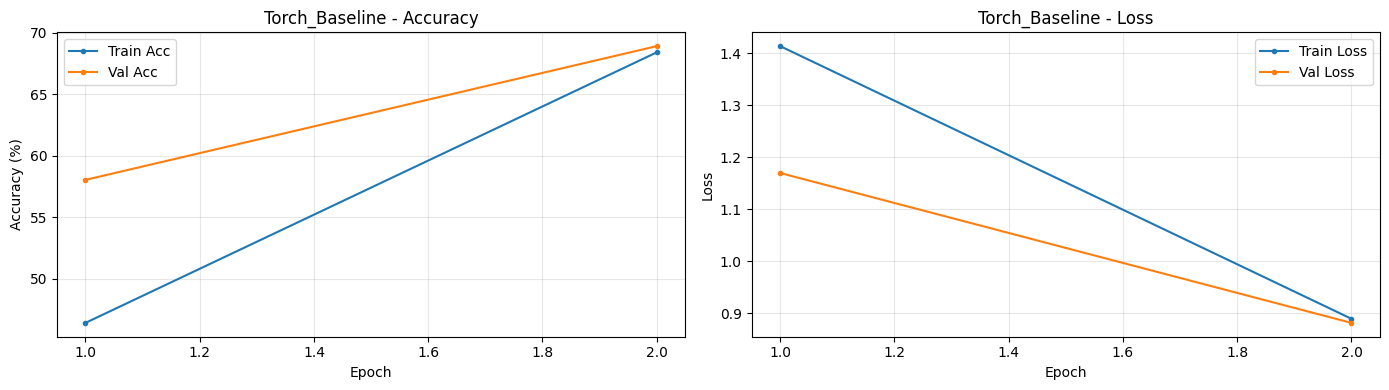

⏱️ train took 71.53s

✅ Baseline Established: 68.91% Accuracy


In [3]:
from reducnn.backends.torch_backend import PyTorchAdapter
t_adapter = PyTorchAdapter(config={'lr': 1e-3})
t_model = t_adapter.get_model("vgg16")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
t_train = DataLoader(torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform), batch_size=128, shuffle=True)
t_test = DataLoader(torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform), batch_size=128)

print("🔥 Training Ground Truth Baseline...")
t_adapter.train(t_model, t_train, epochs=2, name="Torch_Baseline", val_loader=t_test)
b_acc_t = t_adapter.evaluate(t_model, t_test)
b_stats_t = {'FLOPs': t_adapter.get_stats(t_model)[0], 'Params': t_adapter.get_stats(t_model)[1], 'Acc': b_acc_t}
print(f"\n✅ Baseline Established: {b_acc_t:.2f}% Accuracy")

## A.1-A.3: PyTorch Local Bundled Methods

### Local Scope Philosophy:
In local pruning, the framework enforces a strict reduction ratio **per layer**. 
1. **APoZ (Activation)**: Removes filters that produce mostly zero values (dead filters).
2. **Mean Activation (Activation)**: Removes filters with the lowest average activation magnitude.
3. **L1-Norm (Weight)**: Removes filters with the smallest absolute sum of weights.

### Expected Result:
Uniform 30% reduction across all layers. Balanced architecture width.


🔬 PYTORCH LOCAL: APOZ

--- Executing ReduCNN ---
🔍 Analyzing model using 'apoz' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
⏱️ prune took 0.40s


[Heal_apoz] Epoch 1/5: 100%|██████████| 391/391 [00:31<00:00, 12.60it/s, loss=0.5246, acc=80.73%]


📊 Validation: Loss 0.6269, Acc 79.49%


[Heal_apoz] Epoch 2/5: 100%|██████████| 391/391 [00:31<00:00, 12.42it/s, loss=0.3943, acc=85.47%]


📊 Validation: Loss 0.6516, Acc 79.46%


...

📊 Validation: Loss 0.7390, Acc 78.46%


[Heal_apoz] Epoch 4/5: 100%|██████████| 391/391 [00:31<00:00, 12.58it/s, loss=0.4234, acc=89.96%]


📊 Validation: Loss 0.5868, Acc 81.94%


[Heal_apoz] Epoch 5/5: 100%|██████████| 391/391 [00:31<00:00, 12.29it/s, loss=0.2496, acc=91.65%]


📊 Validation: Loss 0.6326, Acc 80.97%


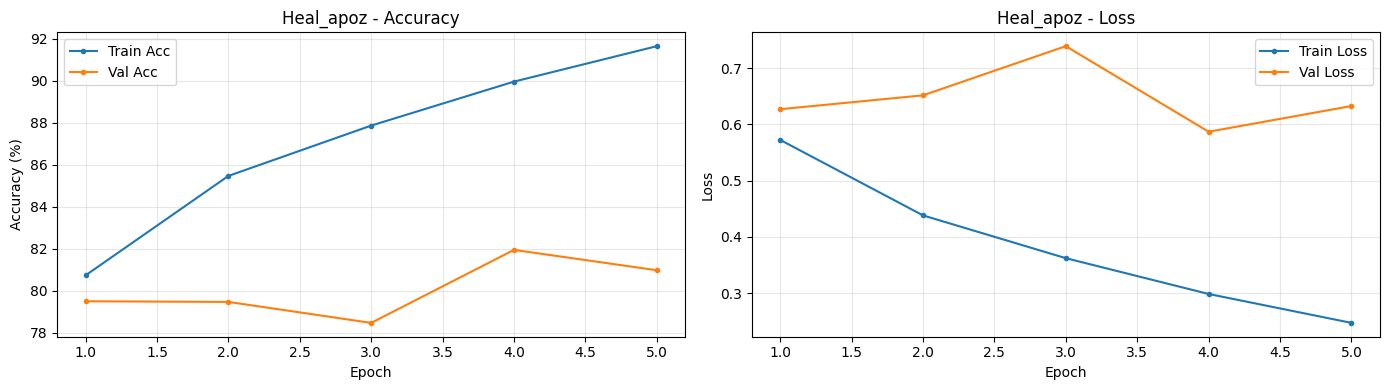

⏱️ train took 172.19s


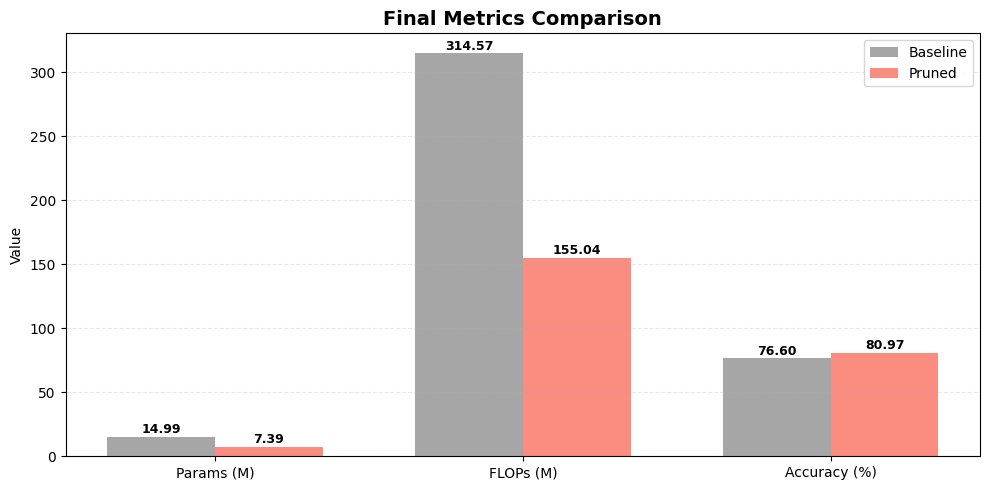

🚀 Business Impact: Model is 2.03x faster (FLOPs reduced by 50.7%).
📉 Accuracy Delta: -4.37%


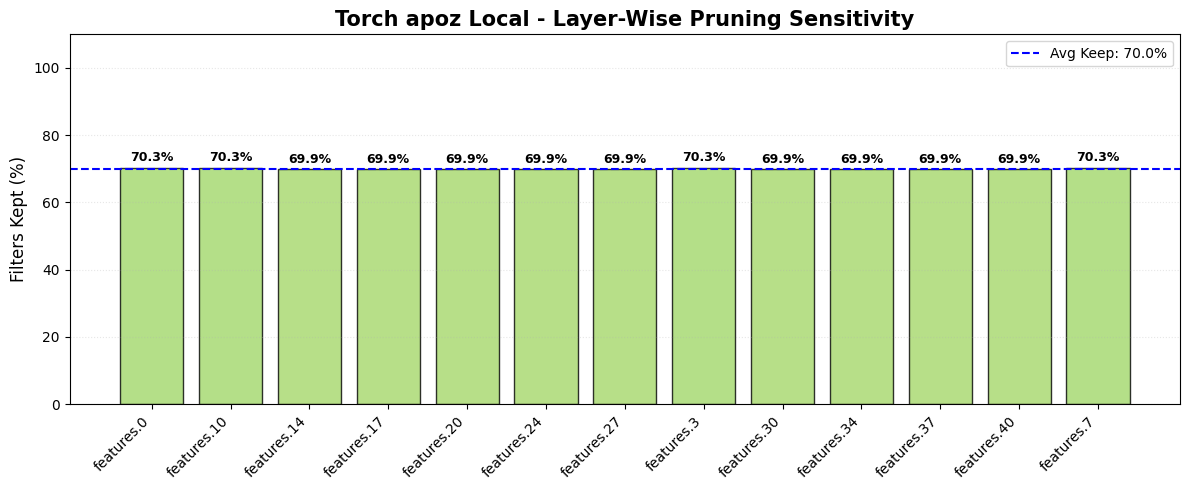


🔬 PYTORCH LOCAL: MEAN_ABS_ACT

--- Executing ReduCNN ---
🔍 Analyzing model using 'mean_abs_act' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
⏱️ prune took 0.34s


[Heal_mean_abs_act] Epoch 1/5: 100%|██████████| 391/391 [00:31<00:00, 12.22it/s, loss=0.4795, acc=80.33%]


📊 Validation: Loss 0.6443, Acc 78.79%


[Heal_mean_abs_act] Epoch 2/5: 100%|██████████| 391/391 [00:31<00:00, 12.56it/s, loss=0.5158, acc=84.99%]


📊 Validation: Loss 0.6292, Acc 79.53%


...

📊 Validation: Loss 0.6018, Acc 80.64%


[Heal_mean_abs_act] Epoch 4/5: 100%|██████████| 391/391 [00:31<00:00, 12.39it/s, loss=0.2069, acc=89.80%]


📊 Validation: Loss 0.6183, Acc 80.89%


[Heal_mean_abs_act] Epoch 5/5: 100%|██████████| 391/391 [00:32<00:00, 12.19it/s, loss=0.3398, acc=91.38%]


📊 Validation: Loss 0.5893, Acc 82.04%


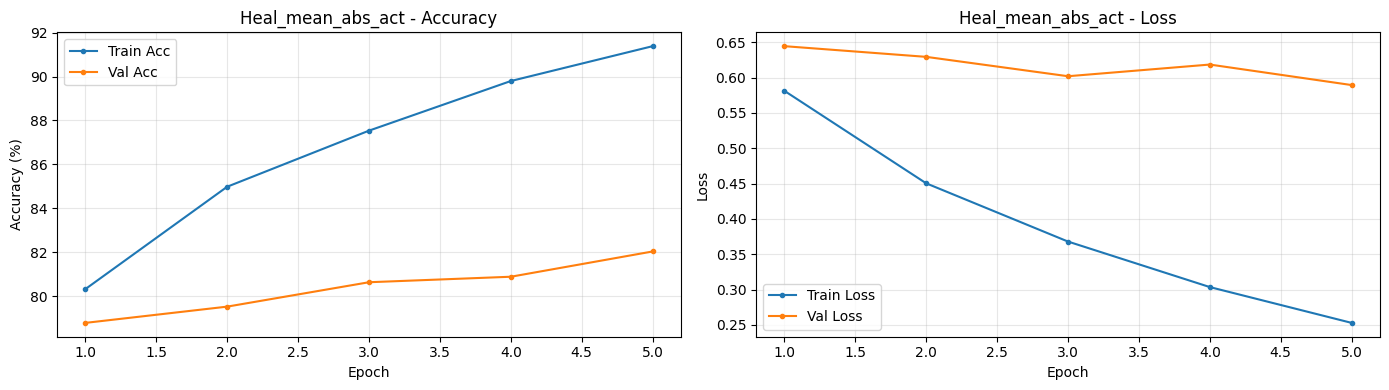

⏱️ train took 174.71s


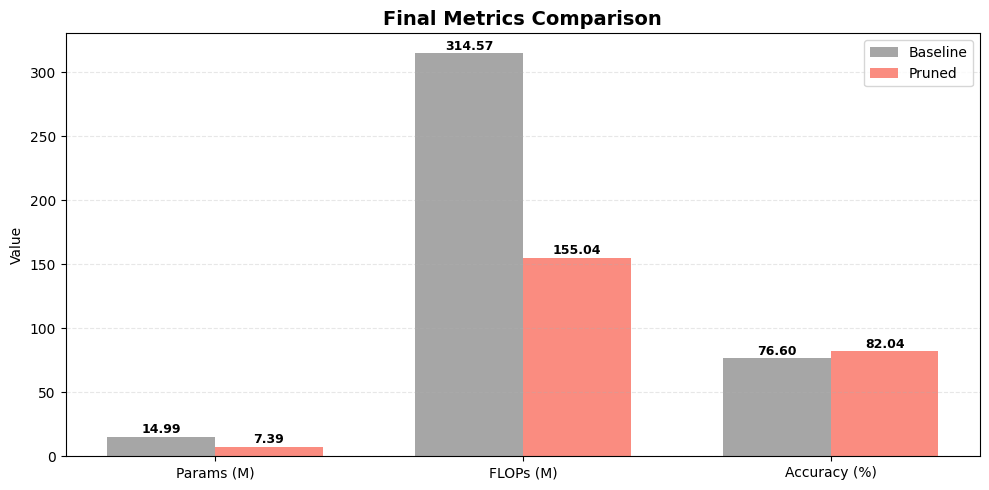

🚀 Business Impact: Model is 2.03x faster (FLOPs reduced by 50.7%).
📉 Accuracy Delta: -5.44%


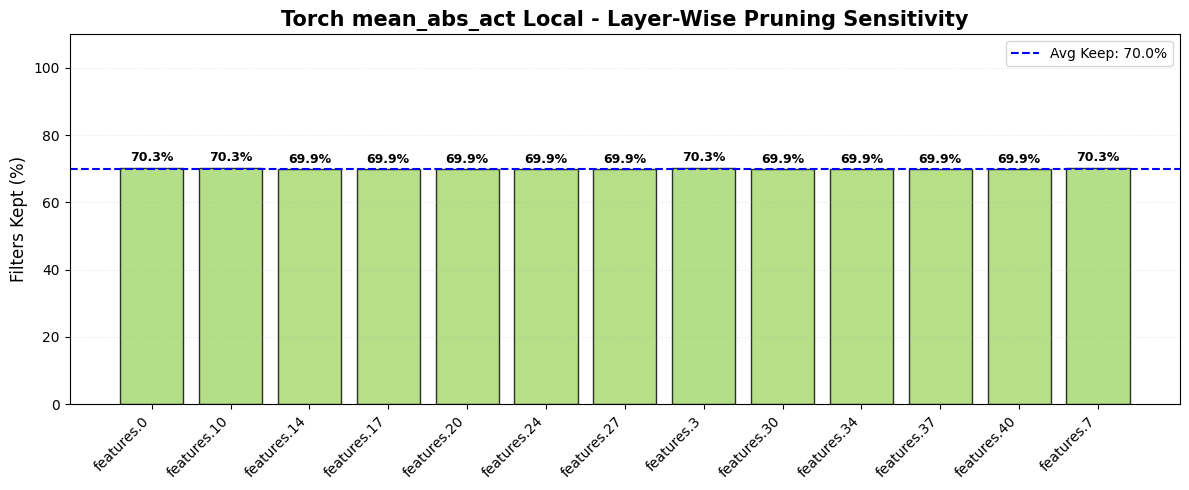


🔬 PYTORCH LOCAL: TAYLOR

--- Executing ReduCNN ---
🔍 Analyzing model using 'taylor' method...


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
⏱️ prune took 0.70s


[Heal_taylor] Epoch 1/5: 100%|██████████| 391/391 [00:31<00:00, 12.34it/s, loss=0.3596, acc=82.09%]


📊 Validation: Loss 0.6076, Acc 79.55%


...

📊 Validation: Loss 0.5888, Acc 81.78%


[Heal_taylor] Epoch 4/5: 100%|██████████| 391/391 [00:31<00:00, 12.42it/s, loss=0.3345, acc=90.03%]


📊 Validation: Loss 0.5832, Acc 82.61%


[Heal_taylor] Epoch 5/5: 100%|██████████| 391/391 [00:31<00:00, 12.51it/s, loss=0.2648, acc=91.94%]


📊 Validation: Loss 0.6211, Acc 82.22%


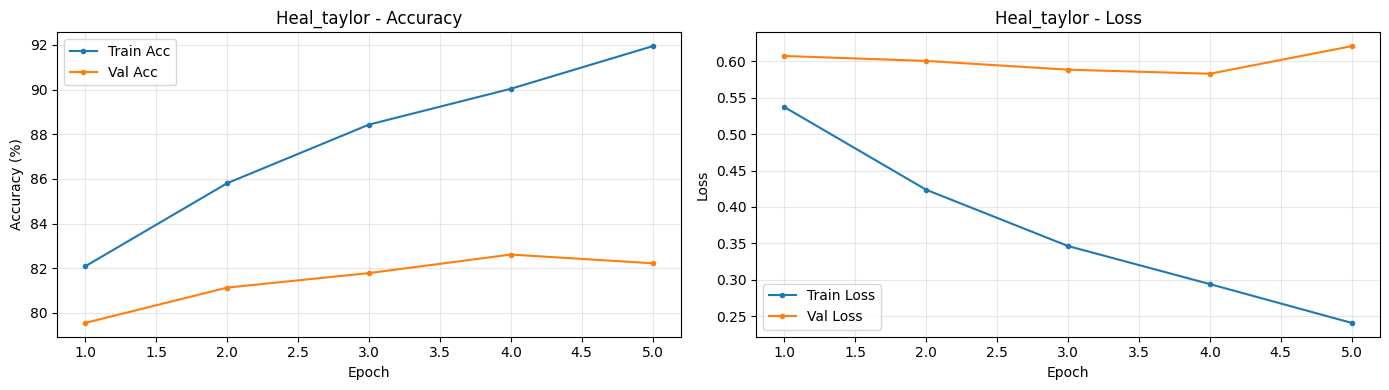

⏱️ train took 172.90s


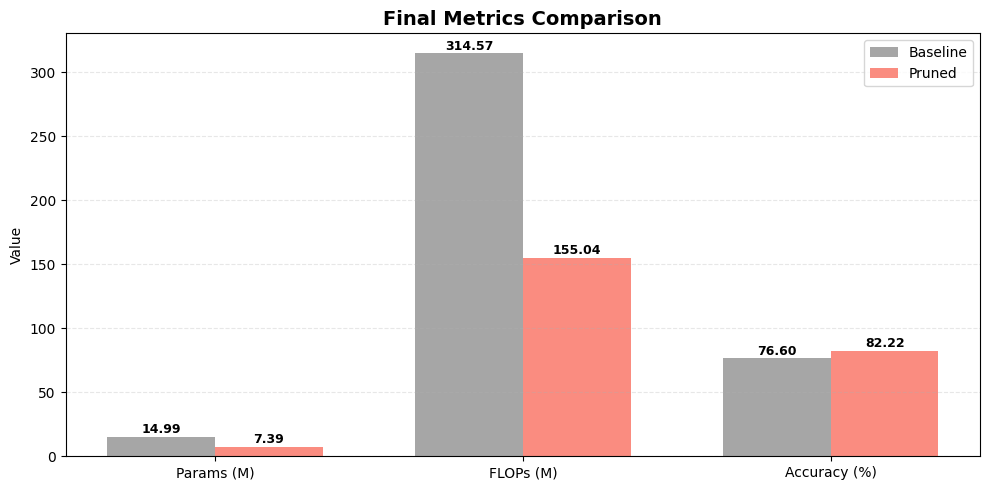

🚀 Business Impact: Model is 2.03x faster (FLOPs reduced by 50.7%).
📉 Accuracy Delta: -5.62%


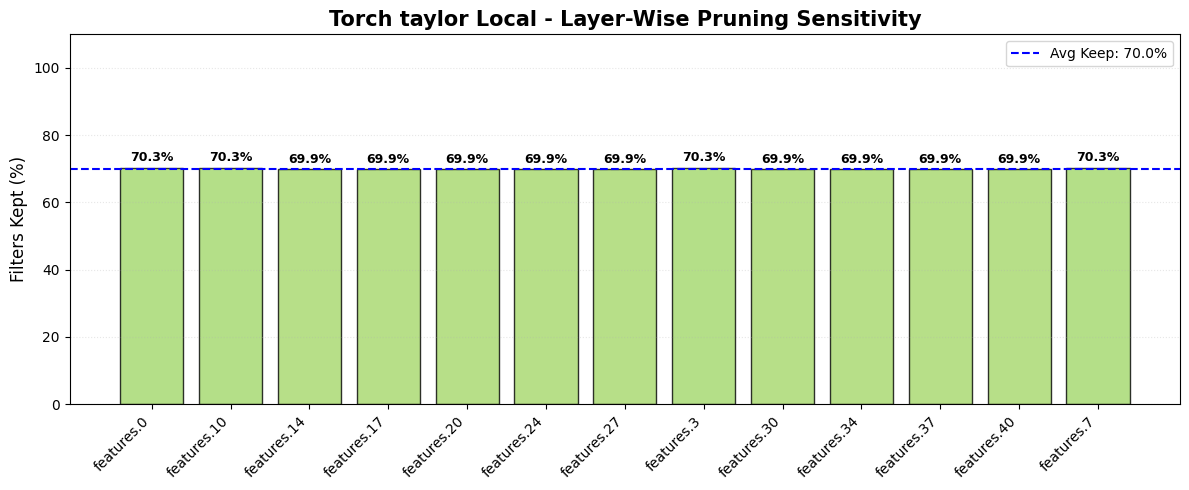

In [ ]:
for method in ['apoz', 'mean_abs_act', 'taylor']:
    print(f"\n🔬 PYTORCH LOCAL: {method.upper()}")
    s = ReduCNNPruner(method=method, scope='local')
    m, masks, dur = s.prune(t_model, t_train, ratio=0.3)
    t_adapter.train(m, t_train, epochs=5, name=f"Heal_{method}", val_loader=t_test)
    viz.plot_metrics_comparison(b_stats_t, {'FLOPs': t_adapter.get_stats(m)[0], 'Params': t_adapter.get_stats(m)[1], 'Acc': t_adapter.evaluate(m, t_test)})
    viz.plot_layer_sensitivity(masks, f"Torch {method} Local")

## A.4-A.6: PyTorch Global Bundled Methods

### Global Scope Philosophy:
In global pruning, we rank **every filter in the model** together. The framework decides which layers are redundant and which are critical.
1. **APoZ (Global)**: Network-wide activation sparsity.
2. **Mean Activation (Global)**: Network-wide activation magnitude.
3. **Taylor (Global)**: The mathematical approximation of loss change using $Abs(Act * Grad)$.

### Expected Result:
Highly variable pruning bars. Some layers might be pruned 0% while others 90%.


🚀 PYTORCH GLOBAL: APOZ

--- Executing ReduCNN ---
🔍 Analyzing model using 'apoz' method...
🏗️ Building masks (scope: global, ratio: 0.5)...
✂️ Applying physical surgery...
⏱️ prune took 0.32s


[Heal_Global_apoz] Epoch 1/2: 100%|██████████| 391/391 [00:27<00:00, 14.00it/s, loss=0.3487, acc=79.50%]


📊 Validation: Loss 0.6095, Acc 80.11%


[Heal_Global_apoz] Epoch 2/2: 100%|██████████| 391/391 [00:28<00:00, 13.84it/s, loss=0.5970, acc=84.71%]


📊 Validation: Loss 0.6542, Acc 78.53%


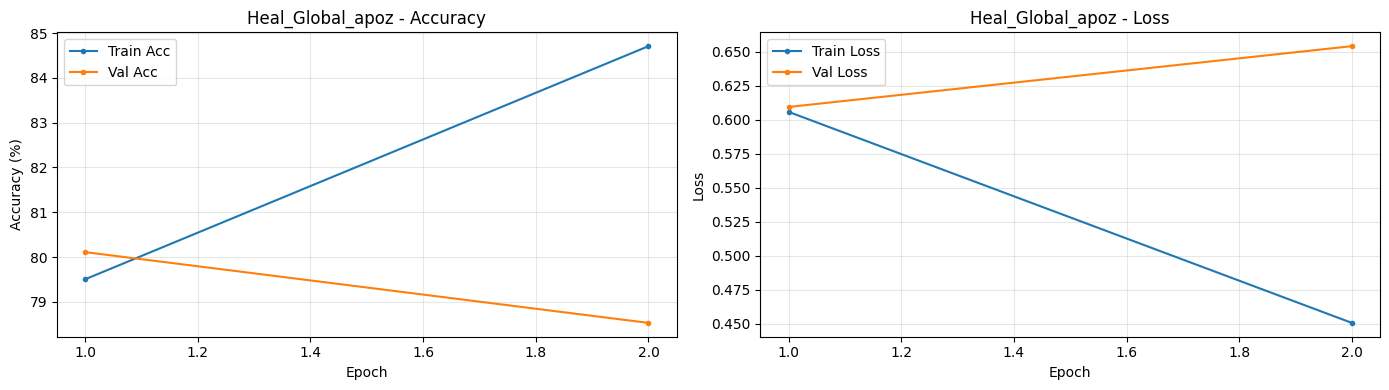

⏱️ train took 62.39s


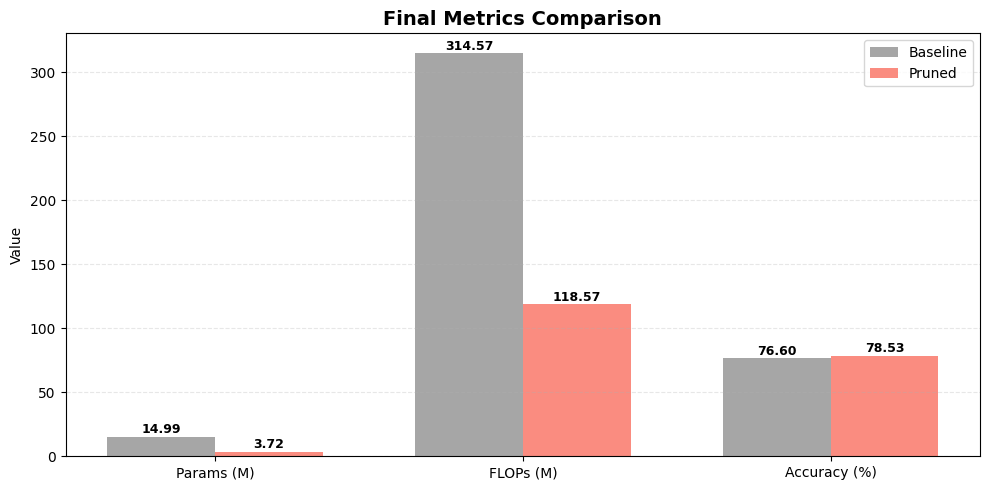

🚀 Business Impact: Model is 2.65x faster (FLOPs reduced by 62.3%).
📉 Accuracy Delta: -1.93%


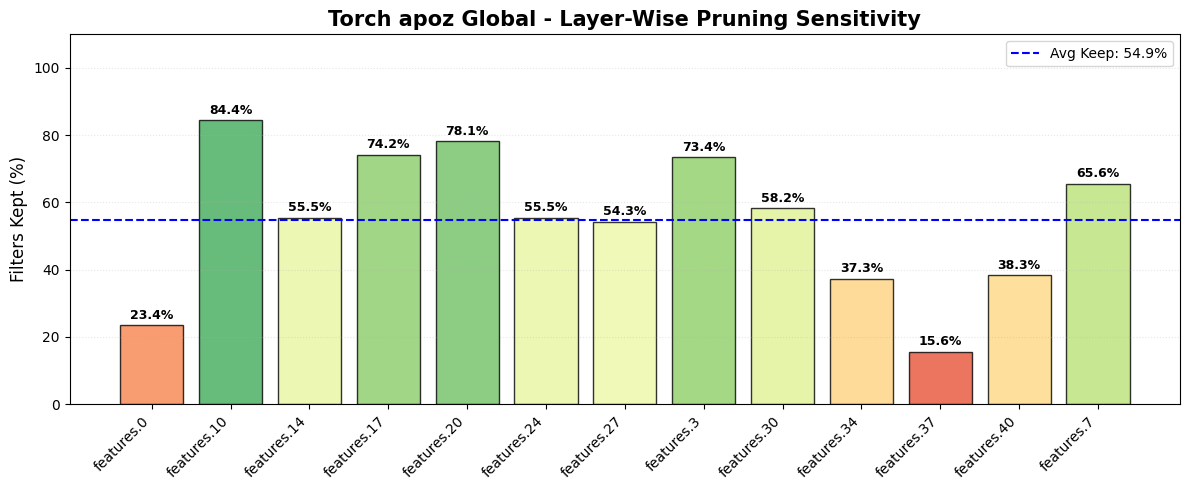


🚀 PYTORCH GLOBAL: TAYLOR

--- Executing ReduCNN ---
🔍 Analyzing model using 'taylor' method...


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


🏗️ Building masks (scope: global, ratio: 0.5)...
✂️ Applying physical surgery...
⏱️ prune took 0.51s


[Heal_Global_taylor] Epoch 1/2: 100%|██████████| 391/391 [00:23<00:00, 16.64it/s, loss=0.6838, acc=62.97%]


📊 Validation: Loss 0.8413, Acc 71.42%


[Heal_Global_taylor] Epoch 2/2: 100%|██████████| 391/391 [00:23<00:00, 16.67it/s, loss=0.7730, acc=74.80%]


📊 Validation: Loss 0.7618, Acc 74.20%


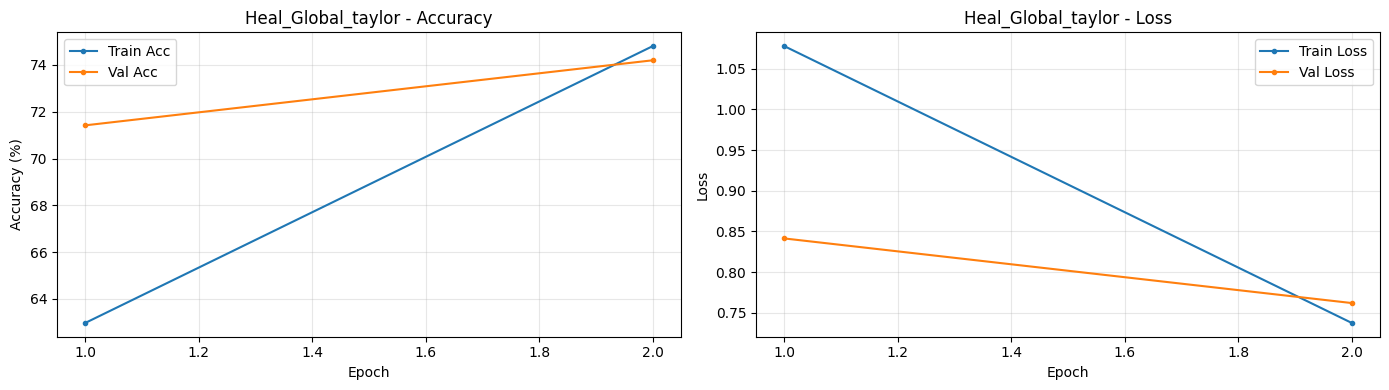

⏱️ train took 52.53s


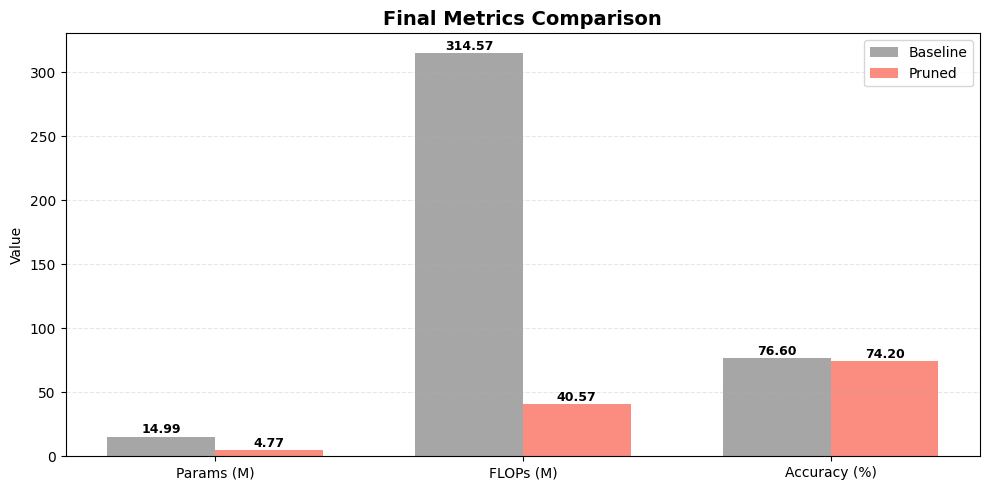

🚀 Business Impact: Model is 7.75x faster (FLOPs reduced by 87.1%).
📉 Accuracy Delta: +2.40%


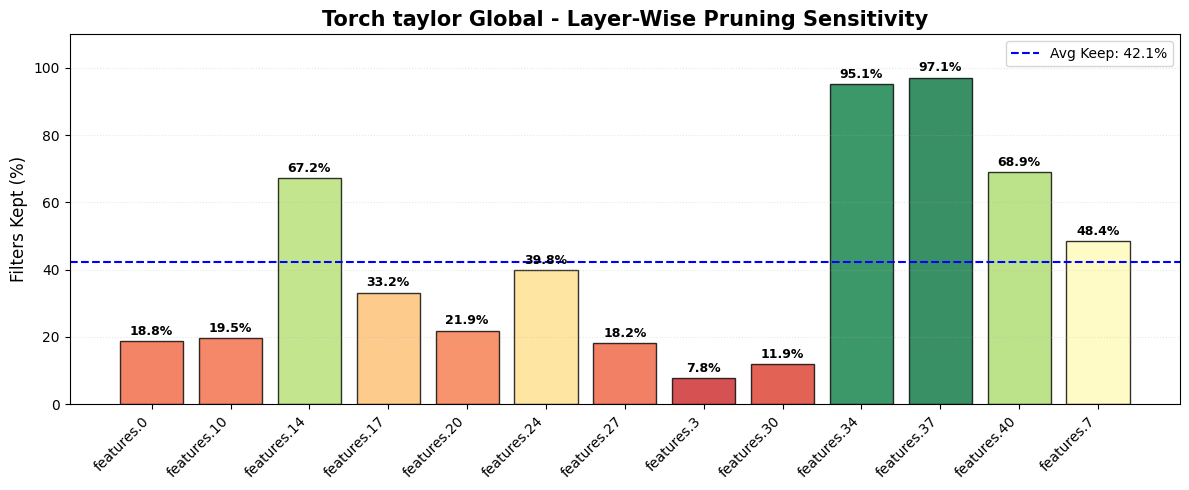

In [5]:
for method in ['apoz', 'taylor']:
    print(f"\n🚀 PYTORCH GLOBAL: {method.upper()}")
    s = ReduCNNPruner(method=method, scope='global')
    m, masks, dur = s.prune(t_model, t_train, ratio=0.5)
    t_adapter.train(m, t_train, epochs=2, name=f"Heal_Global_{method}", val_loader=t_test)
    viz.plot_metrics_comparison(b_stats_t, {'FLOPs': t_adapter.get_stats(m)[0], 'Params': t_adapter.get_stats(m)[1], 'Acc': t_adapter.evaluate(m, t_test)})
    viz.plot_layer_sensitivity(masks, f"Torch {method} Global")

## A.7: Custom Research (CHIP & L2 Norm Override) - PyTorch
Here we demonstrate the **extensibility** of the package. We register custom implementations of **CHIP** (data-dependent) and a custom **L2 Norm** (weight-based) to show how researchers can inject their own math into the pruning engine.

In [6]:
@register_method("custom_l2")
def custom_l2_score(layer, **kwargs):
    """Custom L2 Norm implementation demonstrating registration override."""
    import numpy as np
    l_type = str(type(layer)).lower()
    if "torch" in l_type:
        w = layer.weight.data.cpu().numpy()
        return np.sqrt(np.mean(np.square(w), axis=(1, 2, 3)) + 1e-12)
    else:
        w = layer.get_weights()[0]
        return np.sqrt(np.mean(np.square(w), axis=(0, 1, 2)) + 1e-12)

@register_method("chip")
def chip_math(layer, **kwargs):
    """Scientific implementation of CHIP using matrix rank (Framework Agnostic)."""
    model = kwargs.get('model')
    loader = kwargs.get('loader')
    device = kwargs.get('device', 'cpu')
    if model is None or loader is None: return None

    import numpy as np
    l_type = str(type(layer)).lower()
    activations = []

    if "torch" in l_type:
        import torch
        def hook(m, i, o): 
            if isinstance(o, tuple): o = o[0]
            activations.append(o.detach().cpu().numpy())
        h_handle = layer.register_forward_hook(hook)
        it = iter(loader)
        for _ in range(2):
            try: 
                x, _ = next(it)
                with torch.no_grad(): model(x.to(device))
            except (StopIteration, Exception): break
        h_handle.remove()
        if not activations: return None
        act = np.concatenate(activations, axis=0) # (B, C, H, W)
        b, c, h, w = act.shape
        ranks = [np.linalg.matrix_rank(act[:, i, :, :].reshape(b, -1), tol=1e-5) for i in range(c)]
    else:
        import tensorflow as tf
        probe = tf.keras.Model(inputs=model.input, outputs=layer.output)
        it = iter(loader)
        for _ in range(2):
            try: 
                x, _ = next(it)
                activations.append(probe(x, training=False).numpy())
            except (StopIteration, Exception): break
        if not activations: return None
        act = np.concatenate(activations, axis=0) # (B, H, W, C)
        b, h, w, c = act.shape
        ranks = [np.linalg.matrix_rank(act[:, :, :, i].reshape(b, -1), tol=1e-5) for i in range(c)]
    return np.array(ranks)

print("🧪 Custom methods 'chip' and 'custom_l2' registered.")

🧪 Custom methods 'chip' and 'custom_l2' registered.


## A.7: Custom Research (CHIP & L2 Norm Override) - PyTorch
Here we demonstrate the **extensibility** of the package. We register custom implementations of **CHIP** (data-dependent) and a custom **L2 Norm** (weight-based) to show how researchers can inject their own math into the pruning engine.

In [7]:
@register_method("custom_l2")
def custom_l2_score(layer, **kwargs):
    """Custom L2 Norm implementation for PyTorch."""
    import numpy as np
    w = layer.weight.data.cpu().numpy()
    return np.sqrt(np.mean(np.square(w), axis=(1, 2, 3)) + 1e-12)

@register_method("chip")
def chip_math_torch(layer, **kwargs):
    """CHIP implementation for PyTorch using Nuclear Norm for stability."""
    import torch
    import numpy as np
    model, loader = kwargs.get('model'), kwargs.get('loader')
    device = kwargs.get('device', 'cpu')
    if model is None or loader is None: return None
    
    activations = []
    def hook(m, i, o): 
        if isinstance(o, tuple): o = o[0]
        activations.append(o.detach().cpu().numpy())
    h_handle = layer.register_forward_hook(hook)
    
    model.eval()
    it = iter(loader)
    for _ in range(2):
        try: 
            x, _ = next(it)
            with torch.no_grad(): model(x.to(device))
        except: break
    h_handle.remove()
    
    if not activations: return None
    act = np.concatenate(activations, axis=0) # (B, C, H, W)
    b, c, h, w = act.shape
    scores = [np.linalg.norm(act[:, i, :, :].reshape(b, -1), ord='nuc') for i in range(c)]
    return np.array(scores)

print("🧪 PyTorch custom methods 'chip' and 'custom_l2' registered.")

🧪 Custom methods 'chip' and 'custom_l2' registered.



🧪 PYTORCH CUSTOM: CHIP (Research Extension)

--- Executing ReduCNN ---
🔍 Analyzing model using 'chip' method...
🏗️ Building masks (scope: global, ratio: 0.4)...
✂️ Applying physical surgery...


[Heal_CHIP] Epoch 1/5: 100%|██████████| 391/391 [00:28<00:00, 13.54it/s, loss=1.2001, acc=36.32%]


📊 Validation: Loss 1.4190, Acc 48.11%


[Heal_CHIP] Epoch 2/5: 100%|██████████| 391/391 [00:28<00:00, 13.54it/s, loss=1.0415, acc=57.11%]


📊 Validation: Loss 1.3204, Acc 60.07%


...

📊 Validation: Loss 1.1034, Acc 69.85%


[Heal_CHIP] Epoch 4/5: 100%|██████████| 391/391 [00:28<00:00, 13.61it/s, loss=1.0550, acc=73.69%]


📊 Validation: Loss 1.2511, Acc 67.50%


[Heal_CHIP] Epoch 5/5: 100%|██████████| 391/391 [00:28<00:00, 13.61it/s, loss=0.7946, acc=75.96%]


📊 Validation: Loss 1.1067, Acc 71.64%


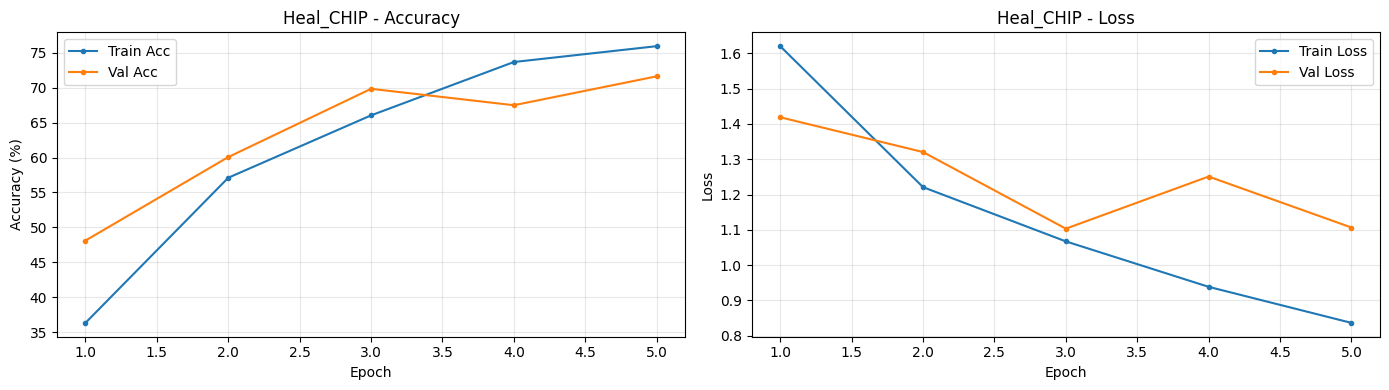

⏱️ train took 161.10s


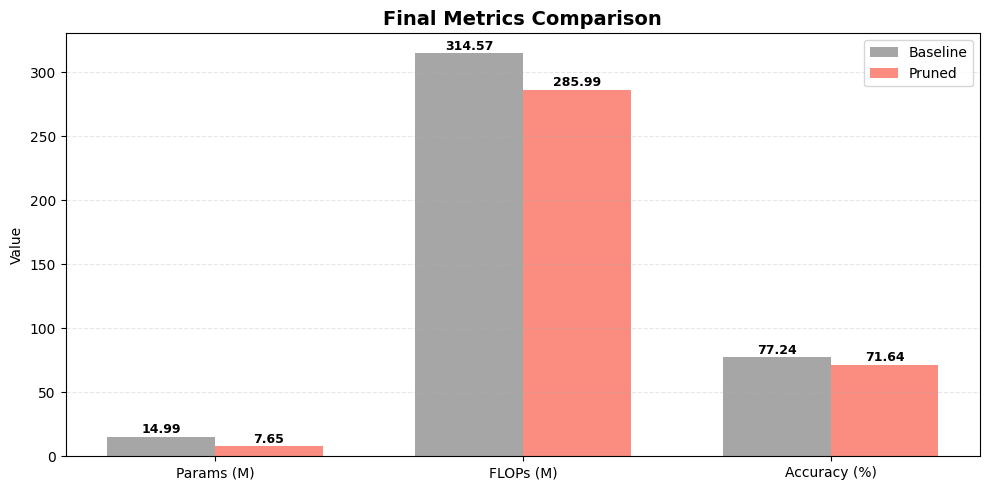

🚀 Business Impact: Model is 1.10x faster (FLOPs reduced by 9.1%).
📉 Accuracy Delta: +5.60%


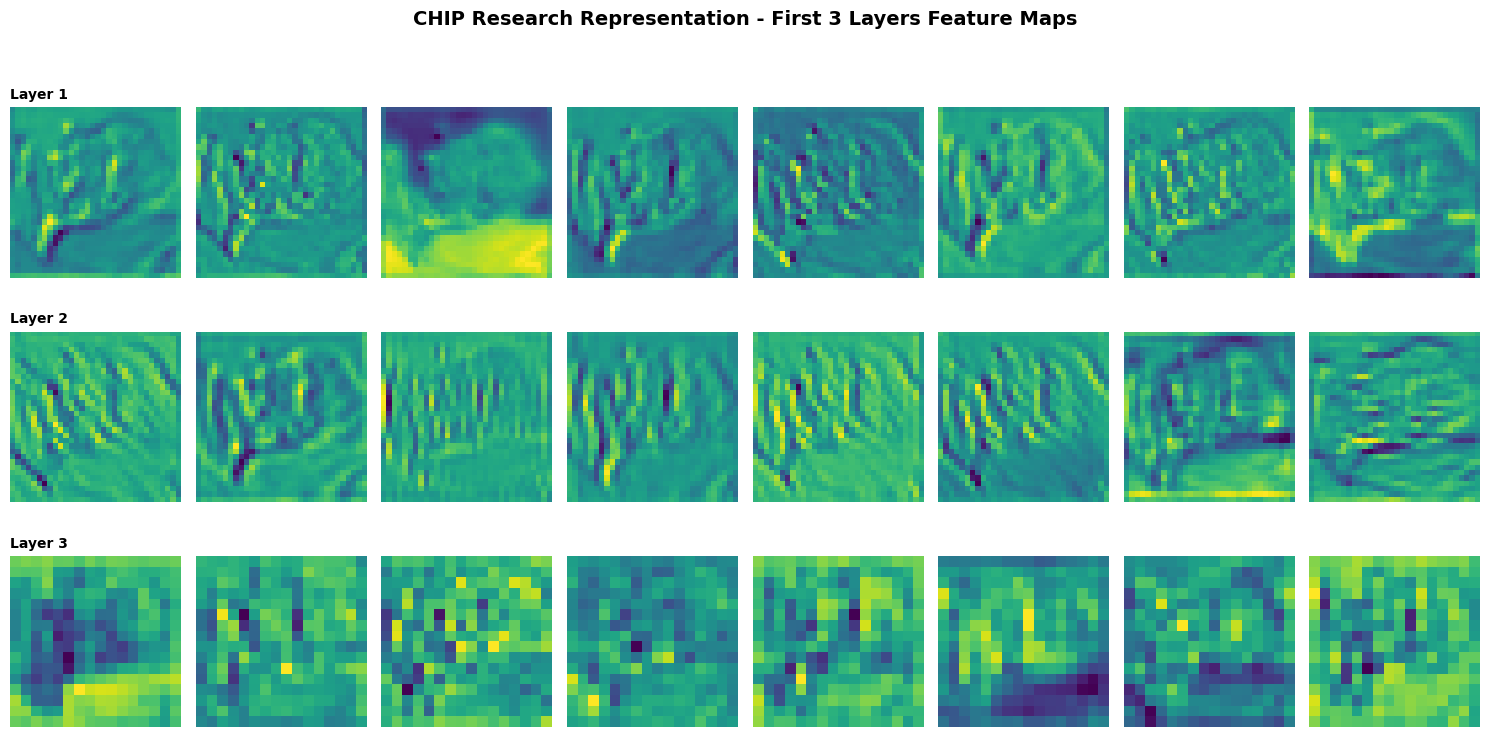

In [9]:
print("\n🧪 PYTORCH CUSTOM: CHIP (Research Extension)")
s = ReduCNNPruner(method='chip', scope='global')
m, masks, dur = s.prune(t_model, t_train, ratio=0.4)
t_adapter.train(m, t_train, epochs=5, name="Heal_CHIP", val_loader=t_test)
viz.plot_metrics_comparison(b_stats_t, {'FLOPs': t_adapter.get_stats(m)[0], 'Params': t_adapter.get_stats(m)[1], 'Acc': t_adapter.evaluate(m, t_test)})
viz.plot_feature_maps(t_adapter.get_viz_data(m, t_test), "CHIP Research Representation")

# Part B: Keras Research Suite
Repeating the symmetric lifecycle for TensorFlow models.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
🔥 Training Keras Baseline...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.3512 - loss: 1.8591📊 Epoch 1/10 - loss: 1.4358 - acc: 0.4775 - val_loss: 1.9120 - val_acc: 0.4619
391/391 ━━━━━━━━━━━━━━━━━━━━ 79s 141ms/step - accuracy: 0.4775 - loss: 1.4358 - val_accuracy: 0.4619 - val_loss: 1.9120
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6714 - loss: 0.9292📊 Epoch 2/10 - loss: 0.8603 - acc: 0.6960 - val_loss: 1.1919 - val_acc: 0.6265
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - accuracy: 0.6960 - loss: 0.8603 - val_accuracy: 0.6265 - val_loss: 1.1919
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7689 - loss: 0.6715📊 Epoch 3/10 - loss: 0.6370 - acc: 0.7819 - val_loss: 1.1899 - val_acc: 0.6492
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 97ms/step - accuracy: 0.7819 - loss: 0.6370 - val_accuracy: 0.6492 - val_loss: 1.1899
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy:

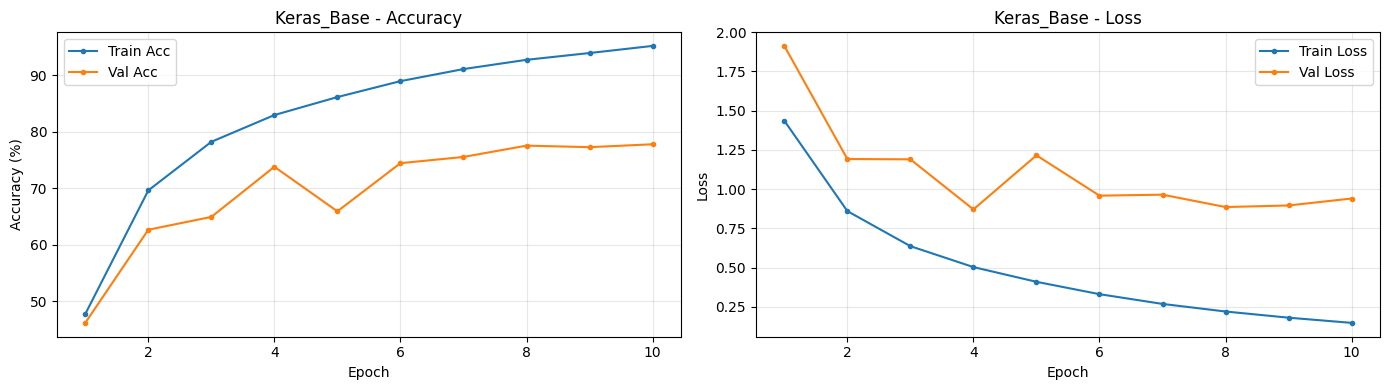

⏱️ train took 419.71s


In [10]:
from reducnn.backends.keras_backend import KerasAdapter
k_adapter = KerasAdapter(config={'lr': 1e-3})
k_model = k_adapter.get_model("vgg16")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
k_train = tf.data.Dataset.from_tensor_slices((x_train/255.0, y_train)).batch(128)
k_test = tf.data.Dataset.from_tensor_slices((x_test/255.0, y_test)).batch(128)

print("🔥 Training Keras Baseline...")
k_adapter.train(k_model, k_train, epochs=10, name="Keras_Base", val_loader=k_test)
b_stats_k = {'FLOPs': k_adapter.get_stats(k_model)[0], 'Params': k_adapter.get_stats(k_model)[1], 'Acc': k_adapter.evaluate(k_model, k_test)}


--- Executing ReduCNN ---
🔍 Analyzing model using 'l1_norm' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9015 - loss: 0.3249📊 Epoch 1/5 - loss: 0.1993 - acc: 0.9355 - val_loss: 0.6774 - val_acc: 0.8225
391/391 ━━━━━━━━━━━━━━━━━━━━ 59s 104ms/step - accuracy: 0.9355 - loss: 0.1993 - val_accuracy: 0.8225 - val_loss: 0.6774
Epoch 2/5
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9742 - loss: 0.0823📊 Epoch 2/5 - loss: 0.0625 - acc: 0.9805 - val_loss: 0.8989 - val_acc: 0.8186
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.9805 - loss: 0.0625 - val_accuracy: 0.8186 - val_loss: 0.8989
Epoch 3/5
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9870 - loss: 0.0402📊 Epoch 3/5 - loss: 0.0380 - acc: 0.9876 - val_loss: 1.1212 - val_acc: 0.8080
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9876 - loss: 0.0380 - val_accuracy: 0.8080 - val_loss: 1.1212
Ep

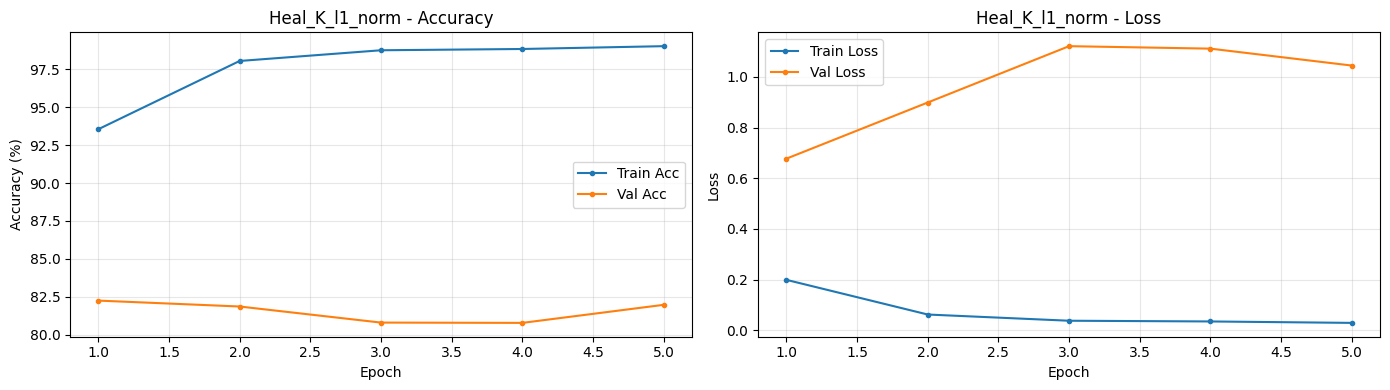

⏱️ train took 161.55s


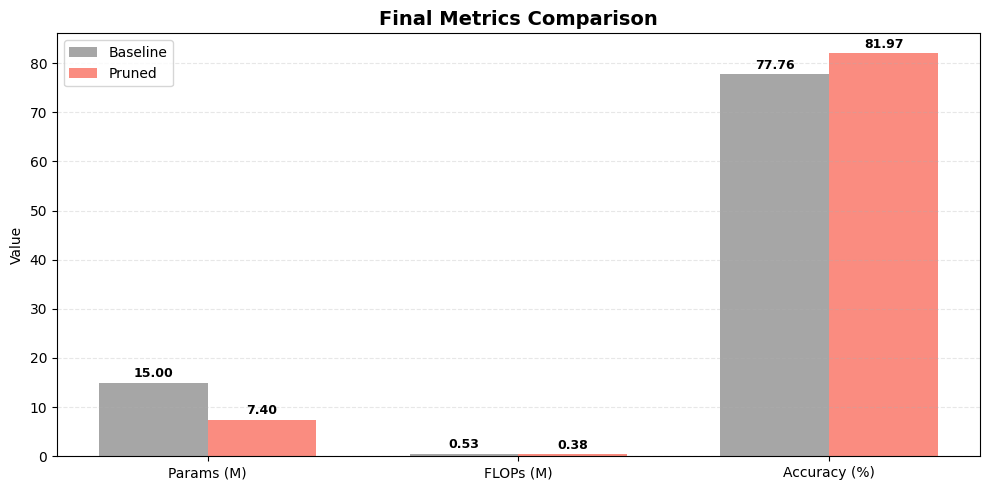

🚀 Business Impact: Model is 1.42x faster (FLOPs reduced by 29.5%).
📉 Accuracy Delta: -4.21%


In [11]:
# 🔬 KERAS LOCAL: l1_norm
method = 'l1_norm'
s = ReduCNNPruner(method=method, scope='local')
m, masks, dur = s.prune(k_model, k_train, ratio=0.3)

k_adapter.train(
    m, 
    k_train, 
    epochs=5, 
    name=f"Heal_K_{method}", 
    val_loader=k_test
)

viz.plot_metrics_comparison(
    b_stats_k, 
    {
        'FLOPs': k_adapter.get_stats(m)[0], 
        'Params': k_adapter.get_stats(m)[1], 
        'Acc': k_adapter.evaluate(m, k_test)
    }
)

In [ ]:
for method in ['apoz', 'mean_abs_act']:
    print(f"\n🔬 KERAS LOCAL: {method.upper()}")
    s = ReduCNNPruner(method=method, scope='local')
    m, masks, dur = s.prune(k_model, k_train, ratio=0.3)
    k_adapter.train(m, k_train, epochs=5, name=f"Heal_K_{method}", val_loader=k_test)
    viz.plot_metrics_comparison(b_stats_k, {'FLOPs': k_adapter.get_stats(m)[0], 'Params': k_adapter.get_stats(m)[1], 'Acc': k_adapter.evaluate(m, k_test)})

In [ ]:
for method in ['apoz', 'mean_abs_act', 'taylor']:
    print(f"\n🚀 KERAS GLOBAL: {method.upper()}")
    s = ReduCNNPruner(method=method, scope='global')
    m, masks, dur = s.prune(k_model, k_train, ratio=0.5)
    k_adapter.train(m, k_train, epochs=1, name=f"Heal_KG_{method}", val_loader=k_test)
    viz.plot_metrics_comparison(b_stats_k, {'FLOPs': k_adapter.get_stats(m)[0], 'Params': k_adapter.get_stats(m)[1], 'Acc': k_adapter.evaluate(m, k_test)})

## B.4: Custom Research (CHIP & L2 Norm Override) - Keras
Similarly, we can inject custom math into the Keras pipeline. Here we register a Keras-compatible **CHIP** (using a probe sub-model) and a custom **L2 Norm**.

In [13]:
@register_method("custom_l2")
def custom_l2_score_keras(layer, **kwargs):
    """Custom L2 Norm implementation for Keras."""
    import numpy as np
    w = layer.get_weights()[0]
    return np.sqrt(np.mean(np.square(w), axis=(0, 1, 2)) + 1e-12)

@register_method("chip")
def chip_math_keras(layer, **kwargs):
    """CHIP implementation for Keras using Nuclear Norm for stability."""
    import tensorflow as tf
    import numpy as np
    model, loader = kwargs.get('model'), kwargs.get('loader')
    if model is None or loader is None: return None
    
    probe = tf.keras.Model(inputs=model.input, outputs=layer.output)
    activations = []
    it = iter(loader)
    for _ in range(2):
        try: 
            x, _ = next(it)
            activations.append(probe(x, training=False).numpy())
        except: break
    
    if not activations: return None
    act = np.concatenate(activations, axis=0) # (B, H, W, C)
    b, h, w, c = act.shape
    scores = [np.linalg.norm(act[:, :, :, i].reshape(b, -1), ord='nuc') for i in range(c)]
    return np.array(scores)

print("🧪 Keras custom methods 'chip' and 'custom_l2' registered.")

🧪 Keras custom methods 'chip' and 'custom_l2' registered.



--- Executing ReduCNN ---
🔍 Analyzing model using 'chip' method...
🏗️ Building masks (scope: global, ratio: 0.3)...
✂️ Applying physical surgery...
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.1509 - loss: 2.0641📊 Epoch 1/5 - loss: 1.9460 - acc: 0.1884 - val_loss: 2.1782 - val_acc: 0.1013
391/391 ━━━━━━━━━━━━━━━━━━━━ 56s 100ms/step - accuracy: 0.1884 - loss: 1.9460 - val_accuracy: 0.1013 - val_loss: 2.1782
Epoch 2/5
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3165 - loss: 1.7114📊 Epoch 2/5 - loss: 1.6466 - acc: 0.3703 - val_loss: 1.8165 - val_acc: 0.3212
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.3703 - loss: 1.6466 - val_accuracy: 0.3212 - val_loss: 1.8165
Epoch 3/5
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4997 - loss: 1.3874📊 Epoch 3/5 - loss: 1.3217 - acc: 0.5225 - val_loss: 1.6433 - val_acc: 0.3930
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.5225 - loss: 1.3217 - val_accuracy: 0.3930 - val_loss: 1.6433
Epoc

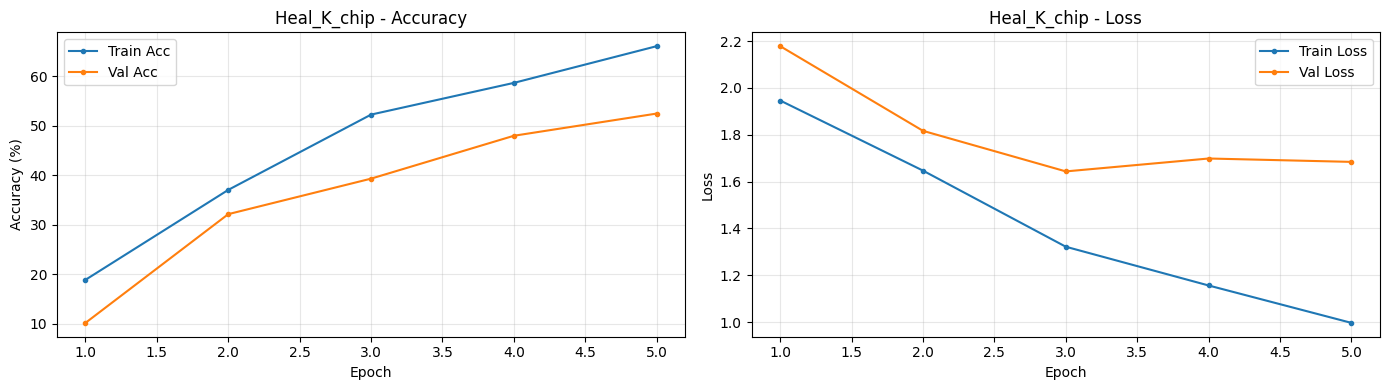

⏱️ train took 163.49s


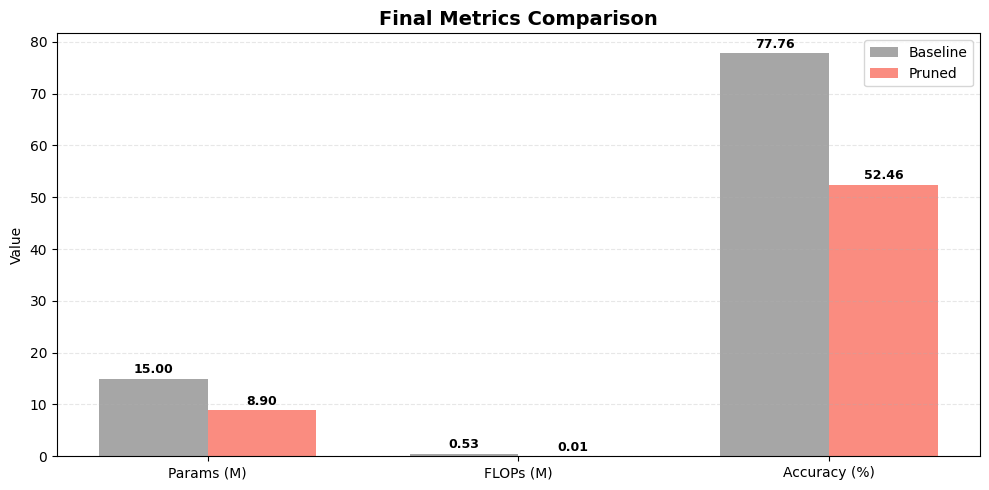

🚀 Business Impact: Model is 47.45x faster (FLOPs reduced by 97.9%).
📉 Accuracy Delta: +25.30%


In [16]:
# 🔬 KERAS Global: chip
method = 'chip'
s = ReduCNNPruner(method=method, scope='global')
m, masks, dur = s.prune(k_model, k_train, ratio=0.3)

k_adapter.train(
    m, 
    k_train, 
    epochs=5, 
    name=f"Heal_K_{method}", 
    val_loader=k_test
)

viz.plot_metrics_comparison(
    b_stats_k, 
    {
        'FLOPs': k_adapter.get_stats(m)[0], 
        'Params': k_adapter.get_stats(m)[1], 
        'Acc': k_adapter.evaluate(m, k_test)
    }
)


--- Executing ReduCNN ---
🔍 Analyzing model using 'custom_l2' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9004 - loss: 0.3315📊 Epoch 1/5 - loss: 0.2001 - acc: 0.9350 - val_loss: 0.6331 - val_acc: 0.8319
391/391 ━━━━━━━━━━━━━━━━━━━━ 50s 90ms/step - accuracy: 0.9350 - loss: 0.2001 - val_accuracy: 0.8319 - val_loss: 0.6331
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9748 - loss: 0.0821📊 Epoch 2/5 - loss: 0.0624 - acc: 0.9808 - val_loss: 1.1301 - val_acc: 0.7978
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9808 - loss: 0.0624 - val_accuracy: 0.7978 - val_loss: 1.1301
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9868 - loss: 0.0417📊 Epoch 3/5 - loss: 0.0380 - acc: 0.9885 - val_loss: 0.9771 - val_acc: 0.8225
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9885 - loss: 0.0380 - val_accuracy: 0.8225 - val_loss: 0.9771
E

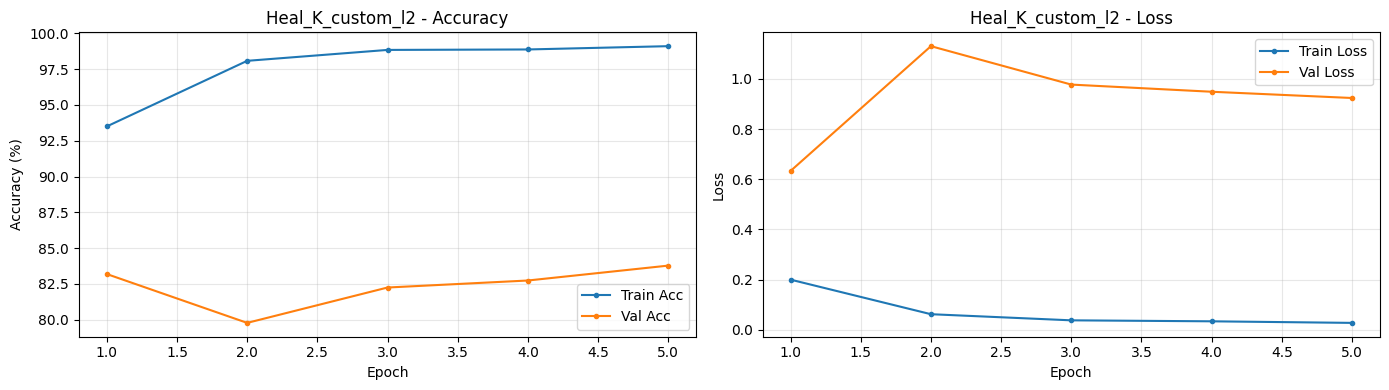

⏱️ train took 154.35s


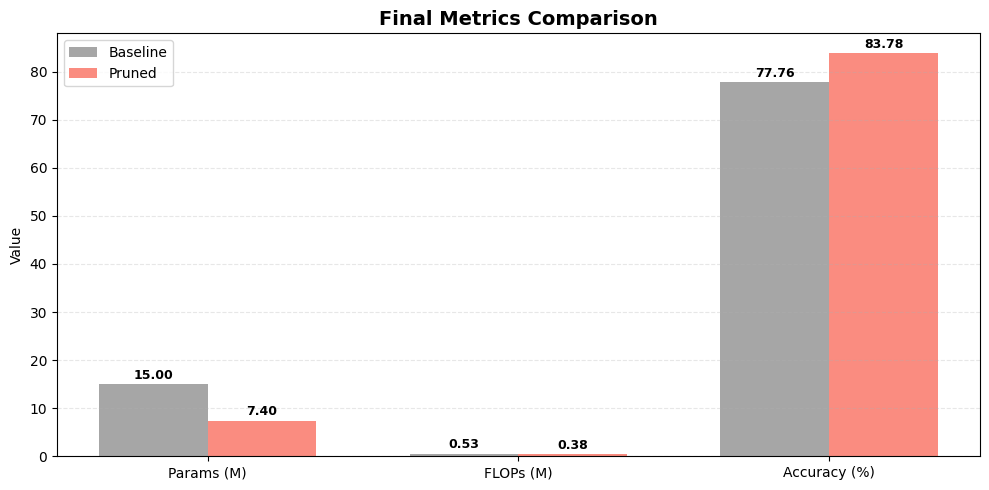

🚀 Business Impact: Model is 1.42x faster (FLOPs reduced by 29.5%).
📉 Accuracy Delta: -6.02%


In [15]:
# 🔬 KERAS Global: chip
method = 'custom_l2'
s = ReduCNNPruner(method=method, scope='local')
m, masks, dur = s.prune(k_model, k_train, ratio=0.3)

k_adapter.train(
    m, 
    k_train, 
    epochs=5, 
    name=f"Heal_K_{method}", 
    val_loader=k_test
)

viz.plot_metrics_comparison(
    b_stats_k, 
    {
        'FLOPs': k_adapter.get_stats(m)[0], 
        'Params': k_adapter.get_stats(m)[1], 
        'Acc': k_adapter.evaluate(m, k_test)
    }
)

# Part C: Advanced Research Concepts

## 1. Dynamic Tracing
ReduCNN v0.6.4 utilizes **Dynamic Tracing** to handle complex architectures like ResNet and DenseNet. Instead of relying on static graph analysis (which often fails on custom PyTorch modules), it performs a "dry run" with a sample input to map every dependency (additions, concatenations, and skip connections) in real-time.

## 2. Pruning Clusters
Pruning is not just about individual layers. In modern architectures, layers are often grouped into **Pruning Clusters**. For example, in a ResNet block, the residual path and the identity path must have the same number of channels at the summation point. ReduCNN automatically identifies these clusters and ensures that pruning decisions are consistent across the entire group.

### C.1 Advanced X-Ray Visualization
The X-Ray animation provides a temporal view of pruning. It shows how the importance scores evolve across layers and how the masks "settle" into a final architecture.

In [ ]:
print("🎬 Generating Pruning X-Ray Animation...")
animator = PruningAnimator(t_adapter)
s_map = t_adapter.get_score_map(t_model, t_train, method='mean_abs_act')
fig = animator.generate_xray_animation(t_model, s_map, masks)
fig.show()

### C.2 DenseNet-121 & CHIP Method (Concatenative Surgery)
DenseNet presents a unique challenge for pruning due to its **Concatenative** topology. Channels from previous layers are carried forward, meaning pruning one layer affects the input offsets of all subsequent layers in the block. ReduCNN v0.6.4 handles this by tracking channel offsets during surgery.

In [ ]:
print("🧪 DenseNet-121 Research (CHIP Method)")
dn_model = t_adapter.get_model('densenet121')
dn_pruner = ReduCNNPruner(method='chip', scope='global')
dn_pruned, dn_masks, _ = dn_pruner.prune(dn_model, t_train, ratio=0.3)
print(f"\n✅ DenseNet-121 Pruned. New Params: {t_adapter.get_stats(dn_pruned)[1]:,.0f}")
viz.plot_layer_sensitivity(dn_masks, "DenseNet-121 CHIP Sensitivity")

# Part D: Hybrid Meta-Pruning (Literature-Grounded) 

This section introduces the **Hybrid Meta-Pruning** method (v0.6.6), which dynamically blends multiple importance metrics using learned or heuristic weighting. This approach is grounded in the works of:
- **Li et al. (2017)**: Pruning Filters for Efficient ConvNets (L1-Norm baseline).
- **Hu et al. (2016)**: Network Trimming via Adaptability Analysis (APoZ).
- **Molchanov et al. (2019)**: Importance Estimation for Neural Network Pruning (Taylor Expansion).

The hybrid method attempts to find the optimal sub-structure by considering both weight magnitude and activation sparsity.

In [ ]:
print('🚀 Executing Hybrid Meta-Pruning...')
hybrid_pruner = ReduCNNPruner(method='hybrid', scope='global')
h_model, h_masks, h_dur = hybrid_pruner.prune(t_model, t_train, ratio=0.5)

print(f'✂️ Hybrid Surgery complete in {h_dur:.2f}s. Healing...')
t_adapter.train(h_model, t_train, epochs=2, name='Hybrid_Heal', val_loader=t_test)

h_acc = t_adapter.evaluate(h_model, t_test)
print(f'✅ Hybrid Pruning Accuracy: {h_acc:.2f}%')

# Visualize the blending profile
print('📊 Blending Profile Heatmap:')
animator = PruningAnimator(t_adapter)
animator.generate_hybrid_heatmap(h_model).show()_hyb_loader = globals().get("t_train", globals().get("train_loader", globals().get("loader", None)))
if _hyb_loader is not None:
    try:
        animator.generate_hybrid_contribution_graph(h_model, _hyb_loader).show()
    except Exception as e:
        print(f"Hybrid contribution graph skipped: {e}")


## Presentation Mode: Visual Diagnostics and Process Flow
This section is designed for demos and slides. It highlights:
1. Dependency graph and residual or concatenation clusters
2. Pruning candidate discovery (lowest-score channels)
3. Interactive X-ray graph walk (Discovery -> Importance -> Consistency -> Shrinkage)
4. Feature map visualization before and after pruning
5. Method agreement diagnostics (optional heavy step)


In [ ]:
# Presentation diagnostics utility (framework-agnostic, v0.6.6)
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import reducnn
import reducnn.visualization as viz
from reducnn.visualization.animator import PruningAnimator
from reducnn.analyzer.validator import MethodValidator

if tuple(map(int, reducnn.__version__.split('.'))) < (0, 6, 6):
    raise RuntimeError(f"Expected reducnn>=0.6.6, found {reducnn.__version__}")

def _resolve_from_globals(name_options):
    g = globals()
    for n in name_options:
        if n in g and g[n] is not None:
            return g[n], n
    return None, None

adapter, adapter_name = _resolve_from_globals(["adapter", "t_res_adapter", "k_adapter", "d_adapter", "dense_adapter"])
orig_model, model_name = _resolve_from_globals(["model", "t_res_model", "res_model", "dense_model", "d_model", "k_model"])
pruned_model, pruned_name = _resolve_from_globals(["pruned_model", "pruned_res", "h_model", "k_pruned", "pruned_dn", "d_pruned"])
masks, masks_name = _resolve_from_globals(["masks", "res_masks", "h_masks", "k_masks", "dn_masks", "d_masks"])
loader, loader_name = _resolve_from_globals(["test_loader", "train_loader", "loader", "val_loader", "t_test", "t_train", "k_test", "k_train"])

print(f"Resolved adapter: {adapter_name}")
print(f"Resolved original model: {model_name}")
print(f"Resolved pruned model: {pruned_name}")
print(f"Resolved masks: {masks_name}")
print(f"Resolved loader: {loader_name}")

if loader is None:
    loader, loader_name = _resolve_from_globals(["t_test", "t_train", "k_test", "k_train"])

if adapter is None or orig_model is None or loader is None:
    raise ValueError("Presentation diagnostics could not resolve adapter/model/loader. Run the main workflow first.")

if masks is None:
    masks = {}

score_method = "taylor"
try:
    score_map = adapter.get_score_map(orig_model, loader, score_method)
except Exception:
    score_method = "l1_norm"
    score_map = adapter.get_score_map(orig_model, loader, score_method)

print(f"Using score method for diagnostics: {score_method}")


In [ ]:
# 0) Optional: load a pre-trained checkpoint from repo/Drive path
# This enables prune-from-checkpoint workflows without baseline retraining.
LOAD_PRETRAINED_CHECKPOINT = False
PRETRAINED_CHECKPOINT_PATH = Path("my_models/pretrained_model.pth")  # Use .weights.h5 for Keras
if LOAD_PRETRAINED_CHECKPOINT:
    if PRETRAINED_CHECKPOINT_PATH.exists():
        adapter.load_checkpoint(orig_model, str(PRETRAINED_CHECKPOINT_PATH))
        print(f"Loaded pretrained checkpoint: {PRETRAINED_CHECKPOINT_PATH.resolve()}")
    else:
        print(f"Pretrained checkpoint not found: {PRETRAINED_CHECKPOINT_PATH}")

# 1) Trace graph and summarize dependency clusters
# Graph nodes = prunable conv nodes in the traced dependency graph.
# Clusters = residual add-linked layers that must share the same mask.
graph = adapter.trace_graph(orig_model)
clusters = graph.get("clusters", {})
print(f"Graph nodes: {len(graph.get('nodes', {}))}")
print(f"Pruning clusters: {len(clusters)}")
for cid, members in list(clusters.items())[:10]:
    print(f"  Cluster {cid}: {members[:8]}{' ...' if len(members) > 8 else ''}")

# 2) Build pruning candidate table (lowest-scoring channels per layer)
# candidate_count uses candidate_ratio (default 20% of each layer).
rows = []
candidate_ratio = 0.2
for layer_name, scores in score_map.items():
    s = np.asarray(scores, dtype=np.float64).reshape(-1)
    k = max(1, int(round(len(s) * candidate_ratio)))
    low_idx = np.argsort(s)[:k]
    rows.append({
        "layer": layer_name,
        "channels": len(s),
        "mean_score": float(np.mean(s)),
        "std_score": float(np.std(s)),
        "candidate_count": int(k),
        "candidate_indices": low_idx.tolist(),
    })

candidate_df = pd.DataFrame(rows).sort_values(["mean_score", "channels"], ascending=[True, False])
print("\nLowest-score candidate layers:")
display(candidate_df.head(20))

# 3) X-ray plotting pipeline
# show_dependency_sweep() prints Stage 1 cluster discovery text output.
# show_shrinkage() prints Stage 3 simulated channel shrink (orig -> kept).
# generate_xray_animation() plots a 4-frame graph: Discovery/Importance/Consistency/Shrink.
animator = PruningAnimator(adapter)
animator.show_dependency_sweep(orig_model)
if masks:
    animator.show_shrinkage(orig_model, masks)

fig = animator.generate_xray_animation(orig_model, score_map, masks)
animator.render(fig)

# 4) Feature map visualization before and after pruning
orig_viz = adapter.get_viz_data(orig_model, loader, num_layers=3)
viz.plot_feature_maps(orig_viz, title_prefix="Original Model")

if pruned_model is not None:
    try:
        pruned_viz = adapter.get_viz_data(pruned_model, loader, num_layers=3)
        viz.plot_feature_maps(pruned_viz, title_prefix="Pruned Model")
    except Exception as e:
        print(f"Skipped pruned feature maps: {e}")

# 5) Optional heavy method-agreement diagnostics
RUN_HEAVY_DIAGNOSTICS = False
if RUN_HEAVY_DIAGNOSTICS:
    methods = ["l1_norm", "apoz", "mean_abs_act", "taylor"]
    MethodValidator().compare_methods(orig_model, loader, methods=methods, ratio=0.3)

# 6) Export artifacts + optional checkpoint persistence
import shutil

EXPORT_ARTIFACTS = True
SAVE_PRUNED_CHECKPOINT = True
SAVE_ORIGINAL_CHECKPOINT = False
COPY_TO_REPO_MODELS_DIR = True

export_dir = Path("exports")
repo_models_dir = Path("my_models")

def _default_ckpt_suffix(model_obj):
    t = str(type(model_obj)).lower()
    return ".weights.h5" if ("keras" in t or "tensorflow" in t) else ".pth"

def _save_ckpt(model_obj, stem_name):
    suffix = _default_ckpt_suffix(model_obj)
    out_path = export_dir / f"{stem_name}{suffix}"
    adapter.save_checkpoint(model_obj, str(out_path))
    print(f"Saved checkpoint: {out_path.resolve()}")
    if COPY_TO_REPO_MODELS_DIR:
        repo_models_dir.mkdir(parents=True, exist_ok=True)
        mirror_path = repo_models_dir / out_path.name
        shutil.copy2(out_path, mirror_path)
        print(f"Mirrored checkpoint: {mirror_path.resolve()}")

if EXPORT_ARTIFACTS:
    export_dir.mkdir(parents=True, exist_ok=True)
    candidate_path = export_dir / "pruning_candidates.csv"
    candidate_df.to_csv(candidate_path, index=False)

    if masks:
        masks_np = {k: np.asarray(v).astype(np.uint8) for k, v in masks.items()}
        np.savez_compressed(export_dir / "pruning_masks.npz", **masks_np)

    if SAVE_ORIGINAL_CHECKPOINT:
        _save_ckpt(orig_model, "original_model")
    if SAVE_PRUNED_CHECKPOINT and pruned_model is not None:
        _save_ckpt(pruned_model, "pruned_model")

    summary = {
        "version": reducnn.__version__,
        "score_method": score_method,
        "nodes": len(graph.get("nodes", {})),
        "clusters": len(clusters),
        "orig_stats": None,
        "pruned_stats": None,
    }
    try:
        summary["orig_stats"] = adapter.get_stats(orig_model, loader)
    except Exception:
        summary["orig_stats"] = adapter.get_stats(orig_model)
    if pruned_model is not None:
        try:
            summary["pruned_stats"] = adapter.get_stats(pruned_model, loader)
        except Exception:
            summary["pruned_stats"] = adapter.get_stats(pruned_model)

    with open(export_dir / "presentation_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2, default=str)

    fig.write_html(str(export_dir / "presentation_pruning_xray.html"))
    print(f"Saved exports to: {export_dir.resolve()}")
